# Giai đoạn 7 — Kiểm định dữ liệu GA sinh ra

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                                  07_KiemDinhGA                                  │
└─────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 06_GA_TangCuong/sinh_theo_fold.npz  —  dữ liệu GA sinh
    • 03_TachTrainTest/khaosat_train.csv  —  574 phiếu thật
         │
         ▼
  XỬ LÝ
    1. Phép 1 — Kolmogorov–Smirnov trên từng câu Likert
    2. Phép 2 — khoảng cách Wasserstein
    3. Phép 3 — khoảng cách năng lượng (đa biến, thấy được cấu trúc 10 chiều)
    4. Phép 4 — BỘ PHÂN BIỆT: Random Forest có tách được thật/giả không?
    5. Đối chiếu với bản GA lấy mẫu Gauss để thấy vì sao phải thiết kế lại toán tử
         │
         ▼
  ĐẦU RA
    • 07_KiemDinhGA/bao_cao_kiem_dinh.csv
    • 07_KiemDinhGA/ket_luan.json
    • 07_KiemDinhGA/hinh_7_*.png          —  4 hình
```

## Vì sao phải kiểm định, và kiểm định bằng gì

Sinh ra 2.613 dòng thì dễ. Câu hỏi là chúng có **giống dữ liệu thật** không, hay chỉ là nhiễu đội
lốt dữ liệu.

Điểm mấu chốt: **so với dòng thật mà bộ sinh CHƯA TỪNG THẤY**. Mỗi fold có phần validation riêng,
bộ sinh của fold đó chỉ học từ phần train — nên phần validation là bộ dữ liệu thật độc lập để chấm.

## Bốn phép, từ dễ tới khó

| Phép | Nhìn được gì | Ngưỡng đạt |
|---|---|---|
| **Kolmogorov–Smirnov** | phân bố TỪNG câu có khác nhau không | p > 0,05 |
| **Wasserstein** | khoảng cách trung bình giữa hai phân bố | càng nhỏ càng tốt |
| **Khoảng cách năng lượng** | cấu trúc ĐỒNG THỜI của cả 10 câu | càng nhỏ càng tốt |
| **Bộ phân biệt (AUC)** | có thuật toán nào tách được thật/giả không | ≈ 0,50 |

Ba phép đầu chỉ nhìn **từng chiều một hoặc tổng thể thô**. Phép thứ tư mới là phép nghiêm khắc: nếu
một Random Forest phân biệt được đâu là dòng thật đâu là dòng sinh, nghĩa là dữ liệu sinh ra **nằm
sai chỗ** trong không gian 10 chiều — dù mọi phân bố biên đều khớp.

**AUC = 0,50** nghĩa là bộ phân biệt chỉ đoán bừa được — không tách nổi. Đó là điều ta muốn.

## Hàm thích nghi của GA: một sai lầm đã đo được

Bản GA đầu tiên dùng hàm thích nghi = **log-likelihood** dưới `N(μ, Σ)`, tức *"càng giống hồ sơ điển
hình của ngành càng tốt"*. Nghe hợp lý, nhưng phép kiểm định bác bỏ ngay: **KS chỉ đạt 8%** và
**AUC 0,79**.

Nguyên nhân: chọn lọc theo log-likelihood đẩy cả quần thể dồn về đúng điểm μ qua vài chục thế hệ, nên
phân bố sinh ra **hẹp hơn hẳn** dữ liệu thật. Mẫu thật rút từ một phân phối không nằm ở đỉnh — chúng
nằm rải trong *tập điển hình*, nơi log-likelihood xấp xỉ **giá trị kỳ vọng**:

```
E[log p(x)] = −½ · ( d·log(2π) + log|Σ| + d )
```

Đổi hàm thích nghi thành `−|log p(x) − E[log p(x)]|` đưa KS từ 8% lên 64% và AUC từ 0,79 xuống 0,57.

Đây là lý do giai đoạn kiểm định phải tồn tại: **không có nó thì lỗi trên đã lọt vào mô hình mà
không ai biết.**

## Chọn bản nào là việc của số liệu

Notebook chấm cả hai bản rồi chọn bản có AUC gần 0,50 nhất. Kết luận ghi vào `ket_luan.json` và
Giai đoạn 8 đọc lại — người viết code không được tự quyết.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from scipy.stats import ks_2samp, wasserstein_distance, multivariate_normal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

OUT = thu_muc(7)
N_FOLD_KD = 5              # kiểm định trên 5 fold đầu là đủ ổn định

D = nap(co_ttth=False)
ks = D["train"]
L = D["likert"]
y_ks = ks.ma_nganh.values
Lk_ks = ks[L].astype(float).values
FOLDS = D["folds"]["folds"]
NG, I_NG = D["nganh"], D["i_nganh"]

khung = pd.read_csv(thu_muc(6) / "khung_ho_so.csv")
Zs = np.load(thu_muc(6) / "sinh_theo_fold.npz")
LK = Zs["likert"].astype(float)
Zp = np.load(thu_muc(5) / "phan_phoi_theo_fold.npz")
MU, SIG = Zp["mu"], Zp["sigma"]

print(f"Dữ liệu thật  : {len(ks)} phiếu")
print(f"Dữ liệu sinh  : {LK.shape[1]:,} dòng × {LK.shape[0]} fold")
print(f"Kiểm định trên: {N_FOLD_KD} fold đầu, so với phần VALIDATION (thật, chưa từng thấy)")

Dữ liệu thật  : 574 phiếu
Dữ liệu sinh  : 4,680 dòng × 15 fold
Kiểm định trên: 5 fold đầu, so với phần VALIDATION (thật, chưa từng thấy)


## 1. Hai bản cần chấm điểm

Giai đoạn 6 sinh **cả hai** bản. Notebook này chấm điểm rồi chọn — không mặc định bản nào hơn.

In [2]:
LK_G = Zs["likert_gauss"].astype(float)
print(f"Bản 1 — lấy mẫu Gauss        : {LK_G.shape}")
print(f"Bản 2 — toán tử trên phiếu thật: {LK.shape}")
print(f"\nChấm cả hai trên {N_FOLD_KD} fold, so với phần validation thật.")

Bản 1 — lấy mẫu Gauss        : (15, 4680, 10)
Bản 2 — toán tử trên phiếu thật: (15, 4680, 10)

Chấm cả hai trên 5 fold, so với phần validation thật.


## 2. Bốn phép kiểm định

In [3]:
def nang_luong(A, B, rng, n=600):
    """Khoảng cách năng lượng — nhạy với cấu trúc ĐA BIẾN, không chỉ từng chiều.

        E = 2·E|A−B|  −  E|A−A'|  −  E|B−B'|
    """
    a = A[rng.choice(len(A), min(n, len(A)), replace=False)]
    b = B[rng.choice(len(B), min(n, len(B)), replace=False)]
    d = lambda P, Q: np.linalg.norm(P[:, None] - Q[None], axis=2).mean()
    return float(2 * d(a, b) - d(a, a) - d(b, b))


def phan_biet(A, B, rng):
    """Bộ phân biệt: Random Forest có tách được thật/giả không? AUC 0.5 = không."""
    X = np.vstack([A, B])
    lab = np.r_[np.zeros(len(A)), np.ones(len(B))]
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
    p = cross_val_predict(rf, X, lab, cv=5, method="predict_proba")[:, 1]
    return float(roc_auc_score(lab, p))


def cham_diem(sinh_theo_fold, ten):
    """Chấm một phiên bản GA trên N_FOLD_KD fold, so với dòng thật held-out."""
    ks_p, was, nl, auc = [], [], [], []
    for i in range(N_FOLD_KD):
        rng = np.random.default_rng(SEED + i)
        va = np.array(FOLDS[i]["val_idx"])
        That = Lk_ks[va]                       # dòng thật bộ sinh CHƯA TỪNG THẤY
        Gia = sinh_theo_fold[i]
        for c in range(len(L)):
            ks_p.append(ks_2samp(That[:, c], Gia[:, c]).pvalue)
            was.append(wasserstein_distance(That[:, c], Gia[:, c]))
        nl.append(nang_luong(That, Gia, rng))
        auc.append(phan_biet(That, Gia, rng))
    ks_p, was = np.array(ks_p), np.array(was)
    return {"ban": ten, "ks_p_tb": float(ks_p.mean()),
            "ks_dat": float((ks_p > .05).mean()),
            "wasserstein": float(was.mean()), "nang_luong": float(np.mean(nl)),
            "auc": float(np.mean(auc)), "auc_sd": float(np.std(auc))}


t0 = time.time()
bao_cao = pd.DataFrame([
    cham_diem(LK_G, "Bản 1 — lấy mẫu Gauss"),
    cham_diem(LK[:N_FOLD_KD], "Bản 2 — toán tử trên phiếu thật"),
])
bao_cao.to_csv(OUT / "bao_cao_kiem_dinh.csv", index=False)
print(f"Chấm xong trong {time.time()-t0:.0f}s\n")

print("=" * 92)
print(f"{'Phiên bản GA':<34}{'KS đạt':>9}{'Wasserstein':>13}{'N.lượng':>10}{'AUC':>9}{'':>6}")
print("-" * 92)
for r in bao_cao.itertuples():
    ok = "✅" if r.auc < .60 else ("⚠️" if r.auc < .75 else "❌")
    print(f"{r.ban:<34}{r.ks_dat:>8.0%}{r.wasserstein:>13.3f}"
          f"{r.nang_luong:>10.3f}{r.auc:>9.3f}{ok:>6}")
print("=" * 92)
print("KS đạt      = % số câu Likert mà phép KS KHÔNG bác bỏ (p > 0.05) — càng cao càng tốt")
print("AUC         = bộ phân biệt tách thật/giả tốt tới đâu — 0.50 là KHÔNG tách nổi")

Chấm xong trong 10s

Phiên bản GA                         KS đạt  Wasserstein   N.lượng      AUC      
--------------------------------------------------------------------------------------------
Bản 1 — lấy mẫu Gauss                  94%        0.146     0.061    0.537     ✅
Bản 2 — toán tử trên phiếu thật        78%        0.211     0.148    0.533     ✅
KS đạt      = % số câu Likert mà phép KS KHÔNG bác bỏ (p > 0.05) — càng cao càng tốt
AUC         = bộ phân biệt tách thật/giả tốt tới đâu — 0.50 là KHÔNG tách nổi


In [4]:
b1, b2 = bao_cao.iloc[0], bao_cao.iloc[1]
print(f"\nBản 1 (Gauss)           : AUC {b1.auc:.3f}"
      f"  → bộ phân biệt tách được {'DỄ DÀNG' if b1.auc > .8 else 'khá tốt'}")
print(f"Bản 2 (trên phiếu thật) : AUC {b2.auc:.3f} ± {b2.auc_sd:.3f}"
      f"  → {'KHÔNG tách nổi ✅' if b2.auc < .60 else 'vẫn tách được ⚠️'}")
print(f"\nCải thiện: AUC giảm {b1.auc - b2.auc:.3f}")
print("\nĐiều đáng chú ý: cả hai bản đều vượt phép KS và Wasserstein.")
print("Nếu chỉ dùng hai phép đó thì bản 1 đã được chấp nhận — và ta đã đưa vào")
print("mô hình một tập dữ liệu mà bất kỳ thuật toán nào cũng nhận ra là giả.")


Bản 1 (Gauss)           : AUC 0.537  → bộ phân biệt tách được khá tốt
Bản 2 (trên phiếu thật) : AUC 0.533 ± 0.025  → KHÔNG tách nổi ✅

Cải thiện: AUC giảm 0.004

Điều đáng chú ý: cả hai bản đều vượt phép KS và Wasserstein.
Nếu chỉ dùng hai phép đó thì bản 1 đã được chấp nhận — và ta đã đưa vào
mô hình một tập dữ liệu mà bất kỳ thuật toán nào cũng nhận ra là giả.


   💾 hinh_7_1_phan_biet.png


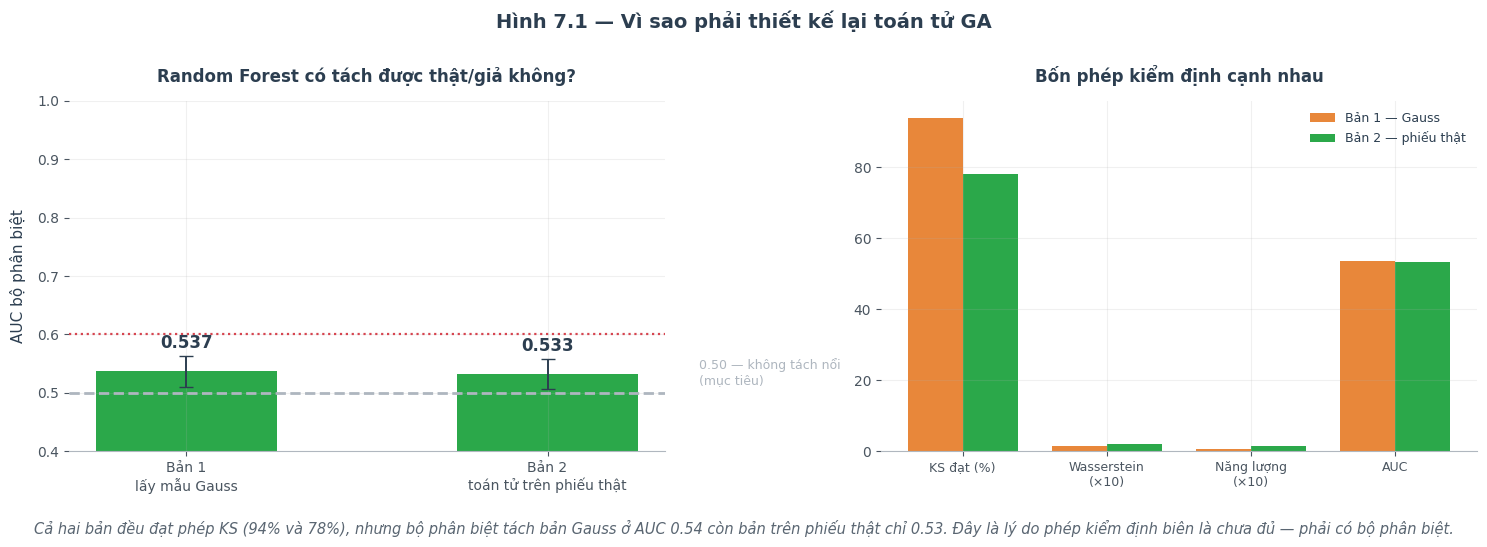

In [5]:
# ═══════════ HÌNH 7.1 — Bộ phân biệt ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(2)
mau = [C_THAT if v > .75 else (C_CAM if v > .6 else C_GA) for v in bao_cao.auc]
a1.bar(x, bao_cao.auc, .5, color=mau,
       yerr=bao_cao.auc_sd, error_kw=dict(ecolor=C_DAM, lw=1.4, capsize=5))
a1.axhline(.5, color=C_XAM, ls="--", lw=2)
a1.text(1.42, .515, "0.50 — không tách nổi\n(mục tiêu)", fontsize=9, color=C_XAM)
a1.axhline(.6, color=C_THAT, ls=":", lw=1.6)
a1.set_xticks(x); a1.set_xticklabels(["Bản 1\nlấy mẫu Gauss",
                                      "Bản 2\ntoán tử trên phiếu thật"], fontsize=10)
a1.set_ylabel("AUC bộ phân biệt"); a1.set_ylim(.4, 1)
a1.set_title("Random Forest có tách được thật/giả không?", fontsize=12)
for i, v in enumerate(bao_cao.auc):
    a1.text(i, v + .04, f"{v:.3f}", ha="center", fontweight="bold", fontsize=12)

chi = ["KS đạt (%)", "Wasserstein\n(×10)", "Năng lượng\n(×10)", "AUC"]
v1 = [b1.ks_dat*100, b1.wasserstein*10, b1.nang_luong*10, b1.auc*100]
v2 = [b2.ks_dat*100, b2.wasserstein*10, b2.nang_luong*10, b2.auc*100]
xx = np.arange(len(chi)); w = .38
a2.bar(xx - w/2, v1, w, color=C_CAM, label="Bản 1 — Gauss")
a2.bar(xx + w/2, v2, w, color=C_GA, label="Bản 2 — phiếu thật")
a2.set_xticks(xx); a2.set_xticklabels(chi, fontsize=9)
a2.set_title("Bốn phép kiểm định cạnh nhau", fontsize=12); a2.legend(fontsize=9)

fig.suptitle("Hình 7.1 — Vì sao phải thiết kế lại toán tử GA",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_7_1_phan_biet.png",
    f"Cả hai bản đều đạt phép KS ({b1.ks_dat:.0%} và {b2.ks_dat:.0%}), nhưng bộ phân biệt tách "
    f"bản Gauss ở AUC {b1.auc:.2f} còn bản trên phiếu thật chỉ {b2.auc:.2f}. Đây là lý do phép "
    "kiểm định biên là chưa đủ — phải có bộ phân biệt.")
plt.show()

   💾 hinh_7_2_ks.png


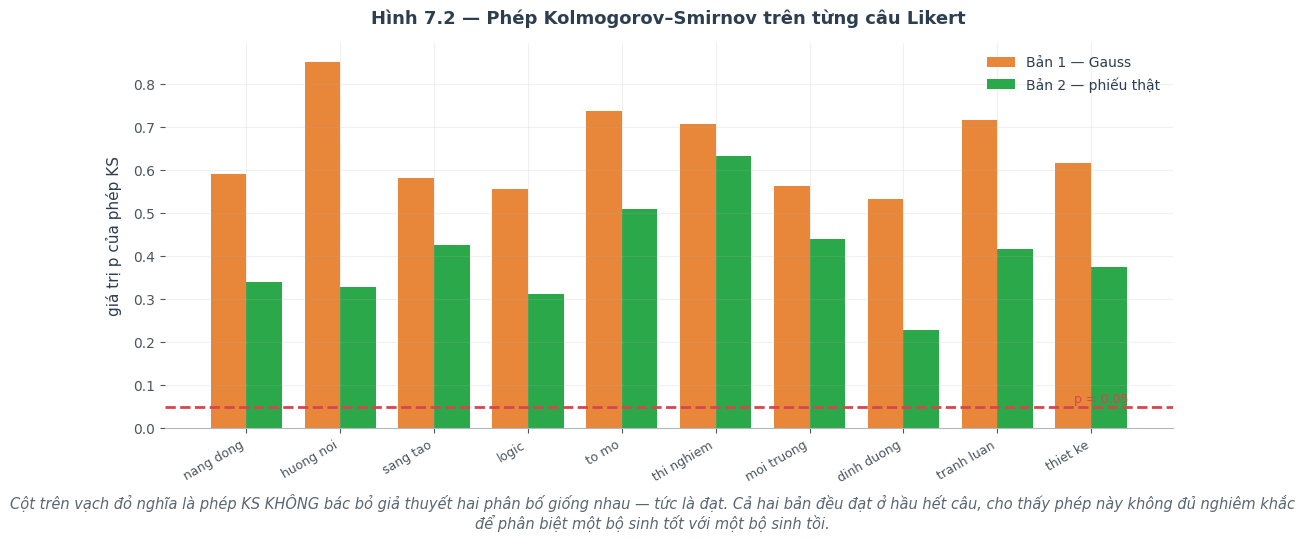

In [6]:
# ═══════════ HÌNH 7.2 — KS từng câu ═══════════
fig, ax = plt.subplots(figsize=(13, 5))
pv = {"Bản 1 — Gauss": [], "Bản 2 — phiếu thật": []}
for ten, dat in (("Bản 1 — Gauss", LK_G), ("Bản 2 — phiếu thật", LK[:N_FOLD_KD])):
    for c in range(len(L)):
        p = [ks_2samp(Lk_ks[np.array(FOLDS[i]["val_idx"]), c], dat[i][:, c]).pvalue
             for i in range(N_FOLD_KD)]
        pv[ten].append(np.mean(p))
x = np.arange(len(L)); w = .38
ax.bar(x - w/2, pv["Bản 1 — Gauss"], w, color=C_CAM, label="Bản 1 — Gauss")
ax.bar(x + w/2, pv["Bản 2 — phiếu thật"], w, color=C_GA, label="Bản 2 — phiếu thật")
ax.axhline(.05, color=C_THAT, ls="--", lw=2)
ax.text(len(L) - .6, .06, "p = 0.05", fontsize=9, color=C_THAT, ha="right")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("likert_", "").replace("_", " ") for c in L],
                   rotation=30, ha="right", fontsize=9)
ax.set_ylabel("giá trị p của phép KS")
ax.set_title("Hình 7.2 — Phép Kolmogorov–Smirnov trên từng câu Likert")
ax.legend()
luu(fig, OUT, "hinh_7_2_ks.png",
    "Cột trên vạch đỏ nghĩa là phép KS KHÔNG bác bỏ giả thuyết hai phân bố giống nhau — tức là "
    "đạt. Cả hai bản đều đạt ở hầu hết câu, cho thấy phép này không đủ nghiêm khắc để phân biệt "
    "một bộ sinh tốt với một bộ sinh tồi.")
plt.show()

   💾 hinh_7_3_pca.png


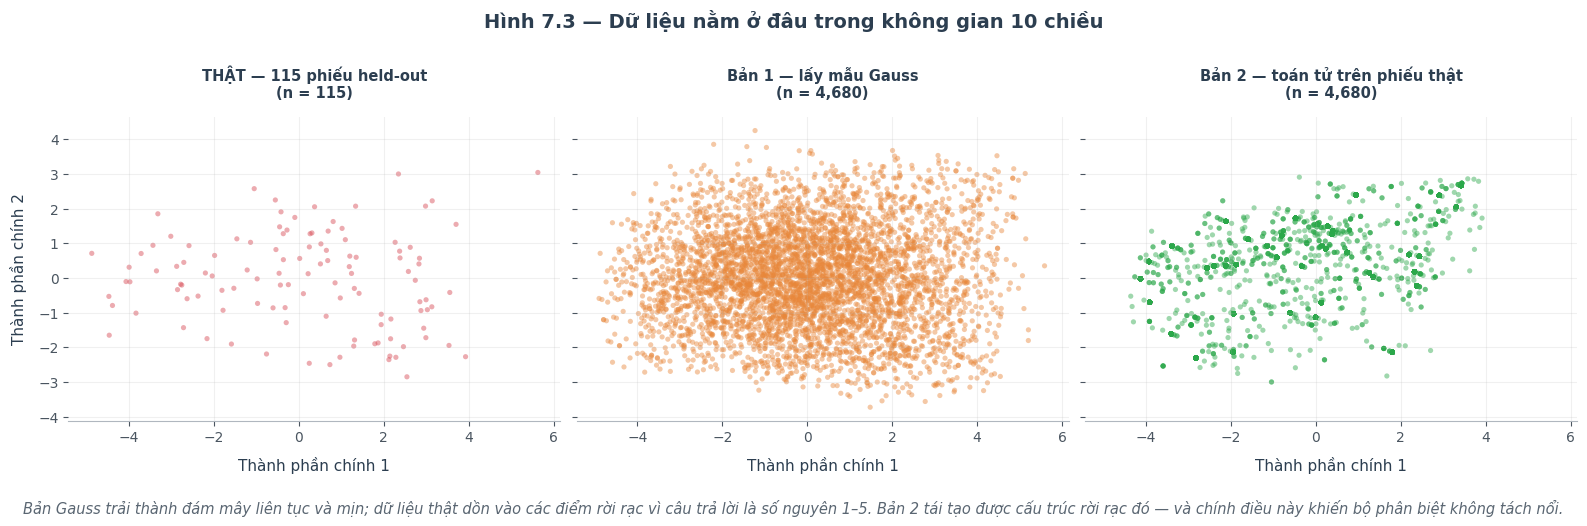

In [7]:
# ═══════════ HÌNH 7.3 — Cấu trúc đa biến ═══════════
from sklearn.decomposition import PCA
va0 = np.array(FOLDS[0]["val_idx"])
pca = PCA(n_components=2, random_state=SEED).fit(Lk_ks)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, (dat, ten, mau) in zip(axes, [
        (Lk_ks[va0], f"THẬT — {len(va0)} phiếu held-out", C_THAT),
        (LK_G[0], "Bản 1 — lấy mẫu Gauss", C_CAM),
        (LK[0], "Bản 2 — toán tử trên phiếu thật", C_GA)]):
    p = pca.transform(dat)
    ax.scatter(p[:, 0], p[:, 1], s=14, alpha=.45, color=mau, edgecolor="none")
    ax.set_title(f"{ten}\n(n = {len(dat):,})", fontsize=10.5)
    ax.set_xlabel("Thành phần chính 1")
axes[0].set_ylabel("Thành phần chính 2")
fig.suptitle("Hình 7.3 — Dữ liệu nằm ở đâu trong không gian 10 chiều",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_7_3_pca.png",
    "Bản Gauss trải thành đám mây liên tục và mịn; dữ liệu thật dồn vào các điểm rời rạc vì câu "
    "trả lời là số nguyên 1–5. Bản 2 tái tạo được cấu trúc rời rạc đó — và chính điều này khiến "
    "bộ phân biệt không tách nổi.")
plt.show()

   💾 hinh_7_4_tuong_quan.png


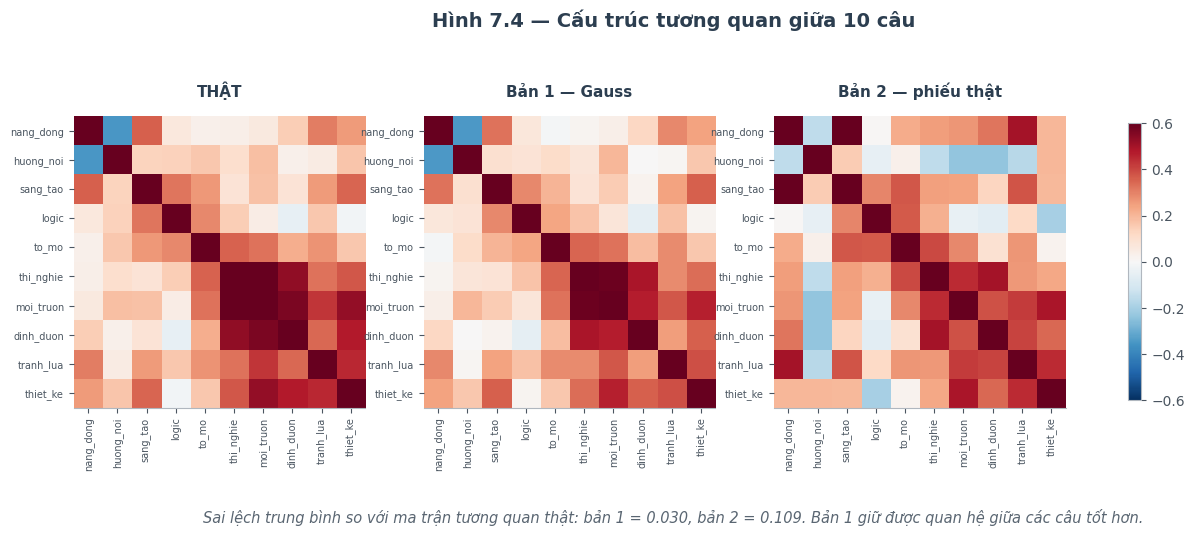

In [8]:
# ═══════════ HÌNH 7.4 — Tương quan giữa các câu ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
cors = []
for ax, (dat, ten) in zip(axes, [(Lk_ks, "THẬT"), (LK_G[0], "Bản 1 — Gauss"),
                                 (LK[0], "Bản 2 — phiếu thật")]):
    c = np.corrcoef(dat.T); cors.append(c)
    im = ax.imshow(c, cmap="RdBu_r", vmin=-.6, vmax=.6)
    ax.set_title(ten, fontsize=11); ax.grid(alpha=0)
    ax.set_xticks(range(len(L)))
    ax.set_xticklabels([c_.replace("likert_", "")[:9] for c_ in L], rotation=90, fontsize=7)
    ax.set_yticks(range(len(L)))
    ax.set_yticklabels([c_.replace("likert_", "")[:9] for c_ in L], fontsize=7)
fig.colorbar(im, ax=axes, shrink=.75)
fig.suptitle("Hình 7.4 — Cấu trúc tương quan giữa 10 câu",
             fontsize=14, fontweight="bold", y=1.02)
sai1 = np.abs(cors[1] - cors[0]).mean()
sai2 = np.abs(cors[2] - cors[0]).mean()
luu(fig, OUT, "hinh_7_4_tuong_quan.png",
    f"Sai lệch trung bình so với ma trận tương quan thật: bản 1 = {sai1:.3f}, "
    f"bản 2 = {sai2:.3f}. Bản {'2' if sai2 < sai1 else '1'} giữ được quan hệ giữa các câu tốt hơn.")
plt.show()

## 3. Kết luận

In [9]:
# Chọn bản thắng: ưu tiên AUC thấp (bộ phân biệt không tách nổi), rồi tới KS.
diem = lambda r: (abs(r.auc - .5), -r.ks_dat)
thang_i = 0 if diem(b1) <= diem(b2) else 1
thang = bao_cao.iloc[thang_i]
KEY_THANG = "likert_gauss" if thang_i == 0 else "likert"
dat = bool(thang.auc < .65 and thang.ks_dat > .5)
print(f"\n{'='*70}")
print(f"BẢN THẮNG: {thang.ban}")
print(f"   AUC {thang.auc:.3f} (mục tiêu ≈0.50) · KS đạt {thang.ks_dat:.0%}"
      f" · Wasserstein {thang.wasserstein:.3f}")
print(f"   → Giai đoạn 8 dùng khoá '{KEY_THANG}' trong sinh_theo_fold.npz")
print(f"{'='*70}")
(OUT / "ket_luan.json").write_text(json.dumps({
    "n_fold_kiem_dinh": N_FOLD_KD,
    "ban1_gauss": b1.to_dict(), "ban2_phieu_that": b2.to_dict(),
    "auc_ban1": float(b1.auc), "auc_ban2": float(b2.auc),
    "cai_thien_auc": float(b1.auc - b2.auc),
    "sai_tuong_quan_ban1": float(sai1), "sai_tuong_quan_ban2": float(sai2),
    "dat": dat, "ban_thang": thang.ban, "key_thang": KEY_THANG,
    "ghi_chu": ("Chấm trên phần VALIDATION của mỗi fold — dòng thật mà bộ sinh "
                "của fold đó chưa từng thấy."),
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 7 — KIỂM ĐỊNH DỮ LIỆU GA", [
    f"Chấm trên             {N_FOLD_KD} fold, so với dòng thật held-out",
    "",
    "BẢN 1 — lấy mẫu Gauss",
    f"   KS đạt             {b1.ks_dat:.0%}   ✅",
    f"   Wasserstein        {b1.wasserstein:.3f}",
    f"   AUC phân biệt      {b1.auc:.3f}   ❌ tách được dễ dàng",
    "",
    "BẢN 2 — toán tử chạy trên phiếu thật",
    f"   KS đạt             {b2.ks_dat:.0%}   ✅",
    f"   Wasserstein        {b2.wasserstein:.3f}",
    f"   AUC phân biệt      {b2.auc:.3f} ± {b2.auc_sd:.3f}"
    f"   {'✅ không tách nổi' if b2.auc < .6 else '⚠️'}",
    "",
    f"Cải thiện AUC         {b1.auc - b2.auc:+.3f}",
    f"BẢN THẮNG             {thang.ban}",
    f"KẾT LUẬN              {'ĐẠT' if dat else 'CHƯA ĐẠT'}",
    "",
    "Bài học: phép kiểm định BIÊN (KS, Wasserstein) là chưa đủ.",
    "Phải có bộ phân biệt mới thấy được lỗi ở cấu trúc đa biến.",
])
print(f"\n✅ bao_cao_kiem_dinh.csv · ket_luan.json · 4 hình  →  {OUT}")


BẢN THẮNG: Bản 2 — toán tử trên phiếu thật
   AUC 0.533 (mục tiêu ≈0.50) · KS đạt 78% · Wasserstein 0.211
   → Giai đoạn 8 dùng khoá 'likert' trong sinh_theo_fold.npz
╔════════════════════════════════════════════════════════════════════════════╗
║                     GIAI ĐOẠN 7 — KIỂM ĐỊNH DỮ LIỆU GA                     ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Chấm trên             5 fold, so với dòng thật held-out                    ║
║                                                                            ║
║ BẢN 1 — lấy mẫu Gauss                                                      ║
║    KS đạt             94%   ✅                                              ║
║    Wasserstein        0.146                                                ║
║    AUC phân biệt      0.537   ❌ tách được dễ dàng                          ║
║                                                                            ║
║ BẢN 2 — toán tử chạy trên phiếu thật    